IPO Performance Analysis and Listing Gain Prediction Using Machine Learning

Objective:
To analyze historical IPO performance and identify factors affecting listing gains using statistical analysis and machine learning techniques.

Tools:
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn

Dataset:
561 IPOs

Machine Learning Models:
1. Linear Regression
2. Random Forest Regressor

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [5]:
df = pd.read_excel("Initial Public Offering.xlsx")

print("Shape:", df.shape)
df.head()

Shape: (561, 21)


,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,...,CMP(NSE),Current Gains,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.0,0.26,...,426.15,10.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,...,199.72,34.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880.0,10.00,...,61.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.0,50.81,...,1062.70,57.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136.0,-13.92,...,150.00,-5.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(df.columns.tolist())

['Date', 'IPO_Name', 'Issue_Size(crores)', 'QIB', 'HNI', 'RII', 'Total', 'Offer Price', 'List Price', 'Listing Gain', 'CMP(BSE)', 'CMP(NSE)', 'Current Gains']


In [7]:
df.columns = [
    'date',
    'ipo_name',
    'issue_size_crores',
    'qib',
    'hni',
    'rii',
    'total_subscription',
    'offer_price',
    'list_price',
    'listing_gain',
    'cmp_bse',
    'cmp_nse',
    'current_gains'
]

In [8]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                561 non-null    datetime64[ns]
 1   ipo_name            561 non-null    object        
 2   issue_size_crores   561 non-null    float64       
 3   qib                 559 non-null    float64       
 4   hni                 559 non-null    float64       
 5   rii                 559 non-null    float64       
 6   total_subscription  559 non-null    float64       
 7   offer_price         561 non-null    int64         
 8   list_price          561 non-null    float64       
 9   listing_gain        561 non-null    float64       
 10  cmp_bse             559 non-null    float64       
 11  cmp_nse             551 non-null    float64       
 12  current_gains       558 non-null    float64       
dtypes: datetime64[ns](1), float64(10), int64(1), objec

In [9]:
print("Total IPOs:", len(df))

print("Average Listing Gain:",
      round(df['listing_gain'].mean(),2))

print("Median Listing Gain:",
      round(df['listing_gain'].median(),2))

print("Highest Listing Gain:",
      round(df['listing_gain'].max(),2))

print("Lowest Listing Gain:",
      round(df['listing_gain'].min(),2))

Total IPOs: 561
Average Listing Gain: 18.03
Median Listing Gain: 7.15
Highest Listing Gain: 252.76
Lowest Listing Gain: -31.73


In [10]:
top10 = df.sort_values(
    by='listing_gain',
    ascending=False
).head(10)

top10[['ipo_name','listing_gain']]

,ipo_name,listing_gain
238,Sigachi Industries Limited,252.76
110,Vibhor Steel Tubes Limited,178.81
242,Paras Defence and Space Technologies Limited,171.43
233,Latent View Analytics,169.04
45,Mamata Machinery Limited,146.91
133,Tata Technologies Limited,139.99
364,Salasar Techno Engineering Ltd,139.95
116,BLS E-Services Limited,128.89
342,Astron Paper & Board Mill Ltd,128.00
81,Premier Energies Limited,120.22


In [11]:
worst10 = df.sort_values(
    by='listing_gain'
).head(10)

worst10[['ipo_name','listing_gain']]

,ipo_name,listing_gain
471,Vaswani Industries Ltd,-31.73
333,Dharan Infra EPC Ltd,-24.44
376,CL Educate Ltd,-20.72
226,Shriram Properties Limited,-20.34
248,Nuvoco Vistas Corporation Limited,-17.37
329,ICICI Securities Ltd,-17.10
335,Bharat Dynamics Ltd,-15.89
415,Pennar Engineered Building Systems Ltd,-15.73
317,Xelpmoc Design and Technologies Ltd,-15.15
270,Kalyan Jewellers India Limited,-15.06


In [12]:
corr = df[
    [
        'issue_size_crores',
        'qib',
        'hni',
        'rii',
        'total_subscription',
        'offer_price',
        'list_price',
        'listing_gain',
        'current_gains'
    ]
].corr()

print(
    corr['listing_gain']
    .sort_values(ascending=False)
)

listing_gain          1.000000
total_subscription    0.721169
hni                   0.628970
qib                   0.621803
rii                   0.515742
list_price            0.277050
current_gains         0.064228
offer_price           0.027911
issue_size_crores    -0.093432
Name: listing_gain, dtype: float64


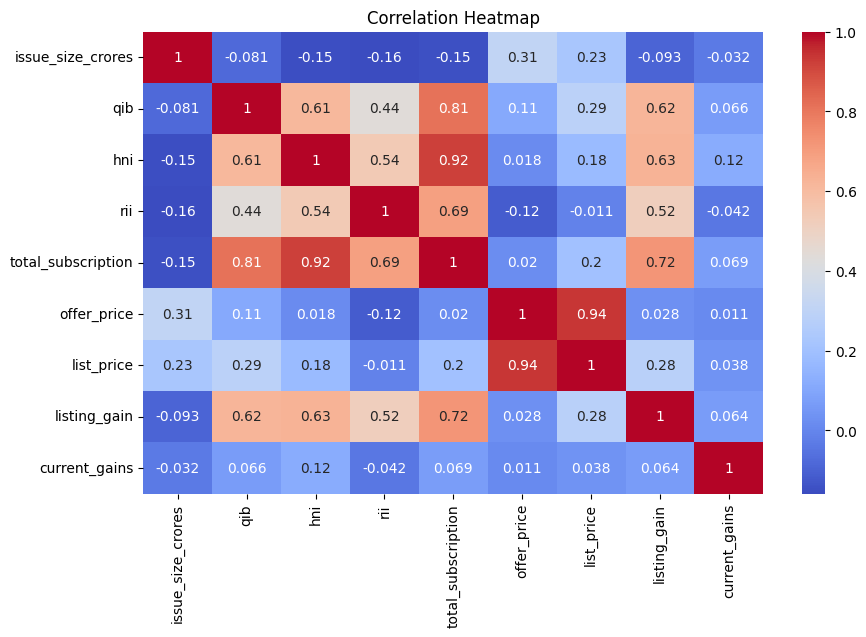

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

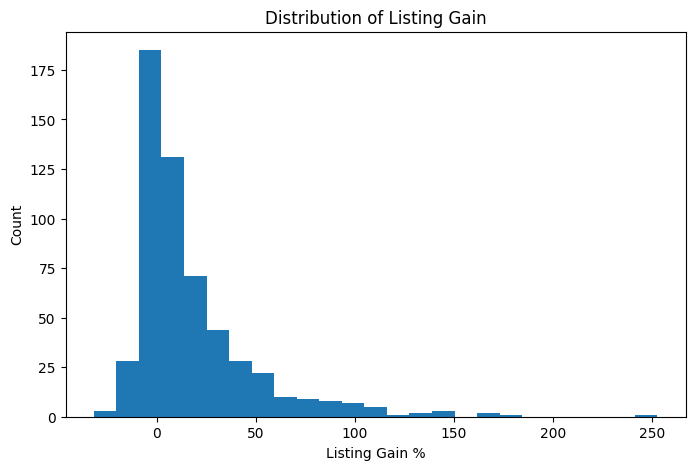

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    df['listing_gain'],
    bins=25
)

plt.title("Distribution of Listing Gain")

plt.xlabel("Listing Gain %")

plt.ylabel("Count")

plt.show()

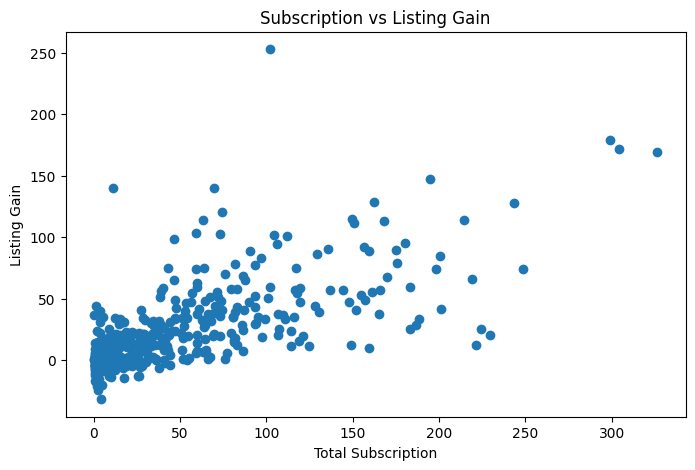

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['total_subscription'],
    df['listing_gain']
)

plt.xlabel("Total Subscription")

plt.ylabel("Listing Gain")

plt.title("Subscription vs Listing Gain")

plt.show()

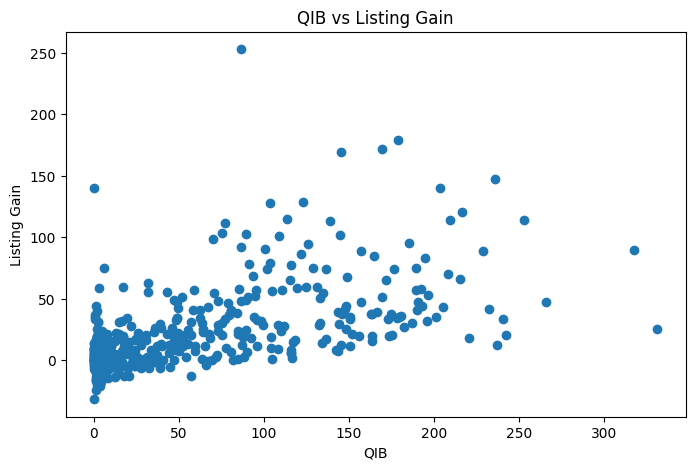

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['qib'],
    df['listing_gain']
)

plt.xlabel("QIB")

plt.ylabel("Listing Gain")

plt.title("QIB vs Listing Gain")

plt.show()

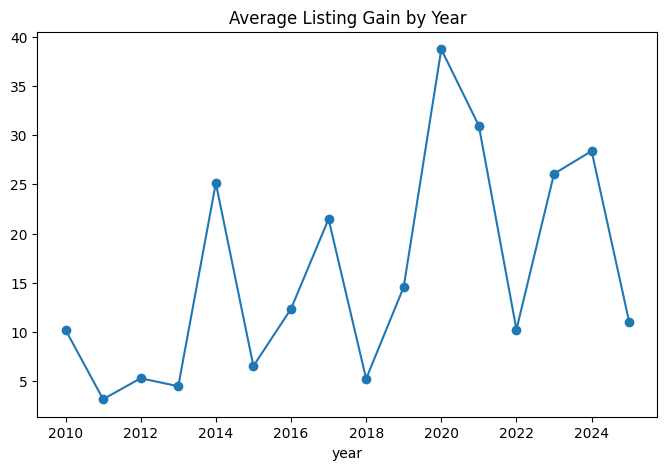

In [17]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year

yearly = (
    df.groupby('year')
      ['listing_gain']
      .mean()
)

yearly.plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.title(
    "Average Listing Gain by Year"
)

plt.show()

In [18]:
features = [
    'issue_size_crores',
    'qib',
    'hni',
    'rii',
    'total_subscription',
    'offer_price'
]

ml_df = df[
    features +
    ['listing_gain']
].dropna()

X = ml_df[features]

y = ml_df['listing_gain']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [20]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

print("Linear Regression")

print(
    "R²:",
    round(
        r2_score(
            y_test,
            lr_pred
        ),
        3
    )
)

print(
    "MAE:",
    round(
        mean_absolute_error(
            y_test,
            lr_pred
        ),
        2
    )
)

print(
    "RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y_test,
                lr_pred
            )
        ),
        2
    )
)

Linear Regression
R²: 0.411
MAE: 16.48
RMSE: 29.31


In [21]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

print("Random Forest")

print(
    "R²:",
    round(
        r2_score(
            y_test,
            rf_pred
        ),
        3
    )
)

print(
    "MAE:",
    round(
        mean_absolute_error(
            y_test,
            rf_pred
        ),
        2
    )
)

print(
    "RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y_test,
                rf_pred
            )
        ),
        2
    )
)

Random Forest
R²: 0.377
MAE: 17.16
RMSE: 30.15


In [22]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance':
    rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
4  total_subscription    0.613981
1                 qib    0.104478
0   issue_size_crores    0.087700
2                 hni    0.079878
3                 rii    0.065527
5         offer_price    0.048435


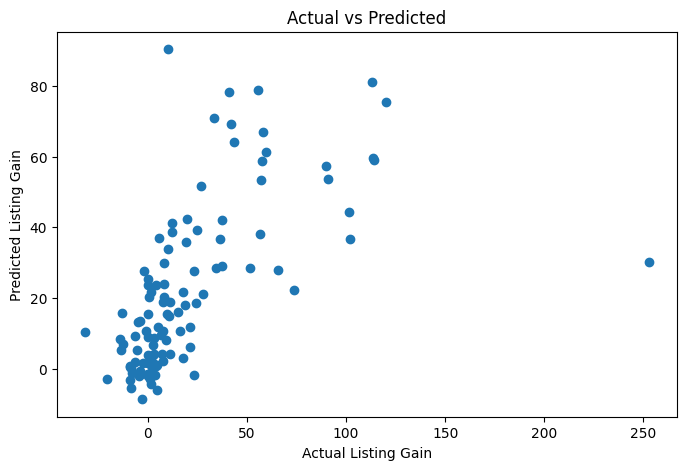

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel(
    "Actual Listing Gain"
)

plt.ylabel(
    "Predicted Listing Gain"
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [24]:
print("""
PROJECT CONCLUSION

1. Total Subscription showed the strongest relationship with listing gains.

2. QIB and HNI participation were important indicators of IPO success.

3. Investor demand had greater impact than issue size.

4. Machine Learning models were able to predict listing gains with moderate accuracy.

5. Subscription metrics can help investors evaluate IPO opportunities.
""")


PROJECT CONCLUSION

1. Total Subscription showed the strongest relationship with listing gains.

2. QIB and HNI participation were important indicators of IPO success.

3. Investor demand had greater impact than issue size.

4. Machine Learning models were able to predict listing gains with moderate accuracy.

5. Subscription metrics can help investors evaluate IPO opportunities.

